# **Image Reconstruction**

In [1]:
# Own modules
from src.utils import show_image, seed_all, MAE, save_model, load_model
from src.data_processing import download_dataset, get_dataset
from src.zhang_model import ZhangColorizationNet
from src.train import train
from src.evaluate import validate_zhang
from src.predict import predict_image_zhang


# Other libraries
import warnings
import os
import torch
import numpy as np
from tqdm import tqdm

# Paths
IMAGES_PATH = "images/"
DATA_PATH = "data/"
MODELS_PATH = "models/"
TEST_IMAGE_PATH = "data/test"

# seed
seed = 42
seed_all(seed)

In [2]:
# CONSTANTS
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
# Loss is weighted cross entropy loss
HYPERPARAMETERS = {
    "size": (256, 256),  # Image size
    "output_classes": 313, # quantized ab bins
    "optimizer": "adam",  # Optimizer
    "learning_rate": 1e-3,  # Learning rate
    "momentum": 0.9,  # Momentum
    "batch_size": 128,  # Batch size
    "epochs": 1,  # Number of epochs
    "num_workers": 4,  # Number of workers for data loading
    "scheduler": "StepLR",  # Learning rate scheduler
    "scheduler_step_size": 5,  # Step size for the scheduler
    "scheduler_gamma": 0.1,  # Gamma for the scheduler
}

**Loading the data**

In [4]:
train_dataset, val_dataset = get_dataset(DATA_PATH, HYPERPARAMETERS["size"], 0.1, "CIELab")

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
train_dataset.image_paths

Fitting MiniBatchKMeans:   0%|          | 0/30504 [00:00<?, ?it/s]/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
Fitting MiniBatchKMeans:   0%|          | 12/30504 [00:00<13:54, 36.53it/s] 

[MiniBatchKMeans] Reassigning 224 cluster centers.


Fitting MiniBatchKMeans:   0%|          | 46/30504 [00:01<12:30, 40.57it/s]

[MiniBatchKMeans] Reassigning 158 cluster centers.
[MiniBatchKMeans] Reassigning 20 cluster centers.


Fitting MiniBatchKMeans:   0%|          | 56/30504 [00:01<11:58, 42.40it/s]

...

Fitting MiniBatchKMeans:   0%|          | 94/30504 [00:02<11:07, 45.58it/s]

[MiniBatchKMeans] Reassigning 6 cluster centers.
[MiniBatchKMeans] Reassigning 27 cluster centers.


Fitting MiniBatchKMeans:  33%|███▎      | 10000/30504 [03:06<06:22, 53.60it/s]


Train dataset size: 27453
Validation dataset size: 3051


['data/train/100006.jpg',
 'data/train/100010.jpg',
 'data/train/100016.jpg',
 'data/train/100021.jpg',
 'data/train/10008.jpg',
 'data/train/100090.jpg',
 'data/train/100111.jpg',
 'data/train/100132.jpg',
 'data/train/100166.jpg',
 'data/train/100199.jpg',
 'data/train/100203.jpg',
 'data/train/100215.jpg',
 'data/train/10023.jpg',
 'data/train/100231.jpg',
 'data/train/100234.jpg',
 'data/train/100238.jpg',
 'data/train/100245.jpg',
 'data/train/100274.jpg',
 'data/train/100283.jpg',
 'data/train/100329.jpg',
 'data/train/100344.jpg',
 'data/train/100354.jpg',
 'data/train/10039.jpg',
 'data/train/10040.jpg',
 'data/train/100404.jpg',
 'data/train/100409.jpg',
 'data/train/100428.jpg',
 'data/train/100430.jpg',
 'data/train/100434.jpg',
 'data/train/100489.jpg',
 'data/train/100539.jpg',
 'data/train/100543.jpg',
 'data/train/100547.jpg',
 'data/train/100553.jpg',
 'data/train/10056.jpg',
 'data/train/100604.jpg',
 'data/train/100678.jpg',
 'data/train/100711.jpg',
 'data/train/1007

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=True,
    num_workers=HYPERPARAMETERS["num_workers"],
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=HYPERPARAMETERS["batch_size"],
    shuffle=False,
    num_workers=HYPERPARAMETERS["num_workers"],
)


**Create the pts_in_hull file**

In [6]:
# Lets create the points in hull file
train_dataset.get_pts_in_hull()

array([[-5.22636271e+00, -4.65804338e+00],
       [ 3.26604958e+01,  9.53054714e+00],
       [-6.74236449e-04,  1.27803953e-03],
       [ 1.10488701e+01, -5.52357197e-01],
       [ 1.57969911e-02, -1.53442430e+00],
       [-1.43587403e-03,  2.72145960e-03],
       [-1.76719844e+00,  6.62941360e+00],
       [ 3.13248386e+01,  3.54920616e+01],
       [-6.33651352e+00,  1.70760894e+00],
       [ 7.07526386e-01,  1.13461280e+00],
       [-1.29153585e+00, -2.44037457e+01],
       [-8.48631287e+00,  3.45207787e+01],
       [-1.25075397e+01,  9.40293121e+00],
       [-2.12315178e+00,  1.33962584e+00],
       [ 1.31525886e+00,  4.95680618e+00],
       [-8.36586638e-04,  1.58585527e-03],
       [-1.37593803e+01,  2.11955700e+01],
       [-1.05959344e+00, -3.51390696e+00],
       [ 2.20026951e+01, -2.96863961e+00],
       [ 2.43360925e+00, -1.14284248e+01],
       [ 6.58033419e+00,  1.19500790e+01],
       [ 9.48504031e-01,  2.20435596e+00],
       [ 6.89678431e-01, -2.80918956e+00],
       [-2.

In [9]:
Q = 313
bin_counts = np.zeros(Q)

subset_size = 5000  # or even 500–1000 for testing
sampled_indices = np.random.choice(len(train_dataset), subset_size, replace=False)

for i in tqdm(sampled_indices, desc="Computing class frequencies"):
    _, label_map = train_dataset[i]
    label_flat = label_map.numpy().flatten()
    bin_counts += np.bincount(label_flat, minlength=Q)
    

# Normalize to get empirical distribution
p_q = bin_counts / np.sum(bin_counts)

# Apply Zhang's smoothing formula
lambda_val = 0.5
w_q = (1 - lambda_val) * p_q + (lambda_val / Q)

# Invert and normalize
weights = 1 / w_q
weights = weights / (np.sum(weights) * Q)

# Save the weights
np.save("class_weights.npy", weights)


Computing class frequencies: 100%|██████████| 5000/5000 [05:04<00:00, 16.40it/s]


In [10]:
weights.shape

(313,)

**Train the model**

In [11]:
model = ZhangColorizationNet(
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=HYPERPARAMETERS["learning_rate"],
)
if HYPERPARAMETERS["scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=HYPERPARAMETERS["scheduler_step_size"],
        gamma=HYPERPARAMETERS["scheduler_gamma"],
    )

# cross entropy loss with class weights
criterion = torch.nn.CrossEntropyLoss(
    weight=torch.from_numpy(weights).float().to(device),
    ignore_index=0,
)


In [16]:
model, train_hist, val_hist = train(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=HYPERPARAMETERS["epochs"],
    scheduler=scheduler,
    device=device,
)




Epoch 1/1 completed in 668.13s
  Train Loss: 5.3449
  Validation Loss: 5.3239


In [17]:
# Create a random name for the model
import random
import string
import datetime
MODEL_NAME = "colorization_model_zhang" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + ''.join(random.choices(string.ascii_lowercase, k=5))
# Save the model
save_model(model, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME, HYPERPARAMETERS)

Model saved at models/colorization_model_zhang20250421_061119_qahft/colorization_model_zhang20250421_061119_qahft.pth
Model parameters saved at models/colorization_model_zhang20250421_061119_qahft/colorization_model_zhang20250421_061119_qahft_params.json


In [10]:
MODEL_NAME = "colorization_model_zhang20250420_104819_fnafq"

In [18]:

# Load the model
model2 = ZhangColorizationNet().to(device)
model, _ = load_model(model2, os.path.join(MODELS_PATH, MODEL_NAME), MODEL_NAME)



**Prediction**

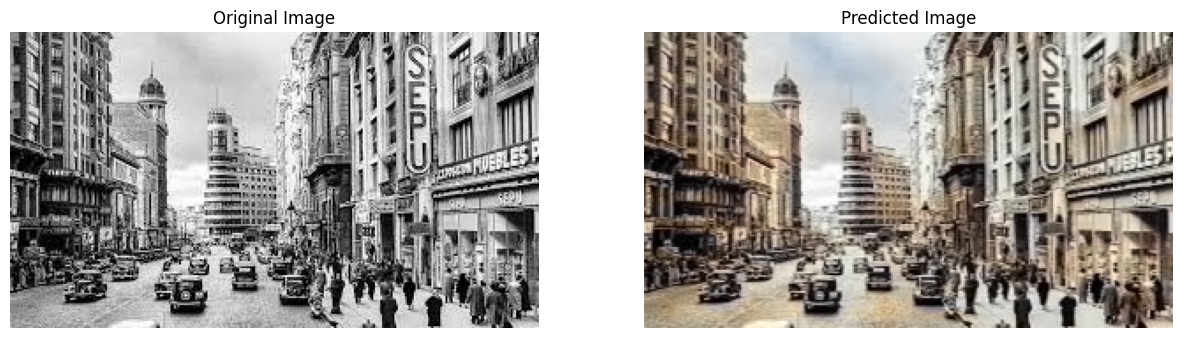

Prediction saved at models/pred_old_madrid.jpeg


<Figure size 640x480 with 0 Axes>

In [19]:
test_image = "old_madrid.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

# pass a path that saves the image in the models folder
show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))


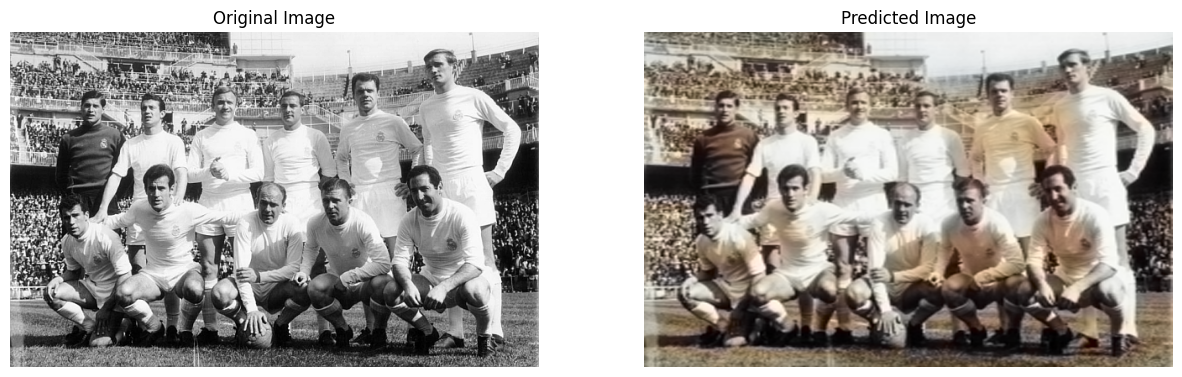

Prediction saved at models/pred_real_madrid.jpg


<Figure size 640x480 with 0 Axes>

In [20]:
test_image = "real_madrid.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))

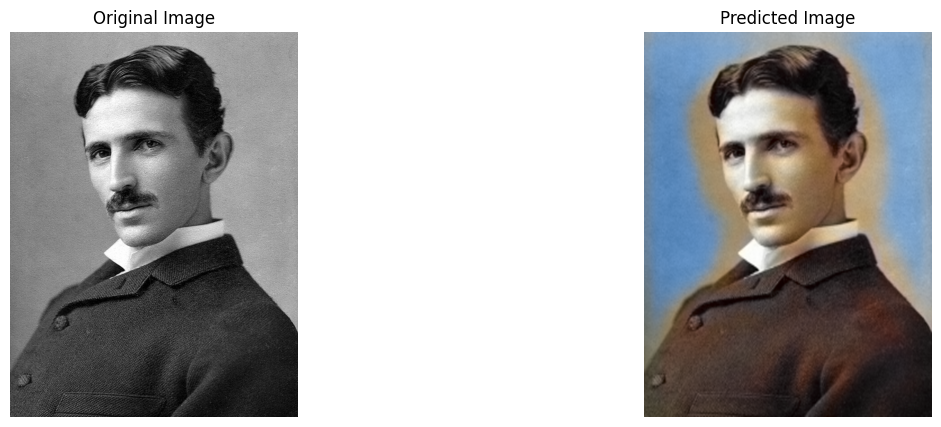

Prediction saved at models/pred_tesla.jpeg


<Figure size 640x480 with 0 Axes>

In [21]:
test_image = "tesla.jpeg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))

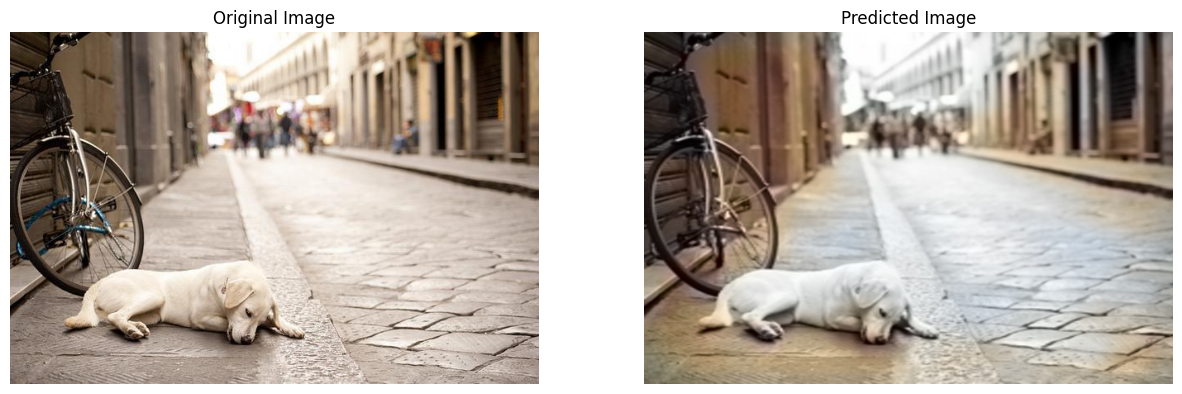

Prediction saved at models/pred_dog.jpg


<Figure size 640x480 with 0 Axes>

In [23]:
test_image = "dog.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))

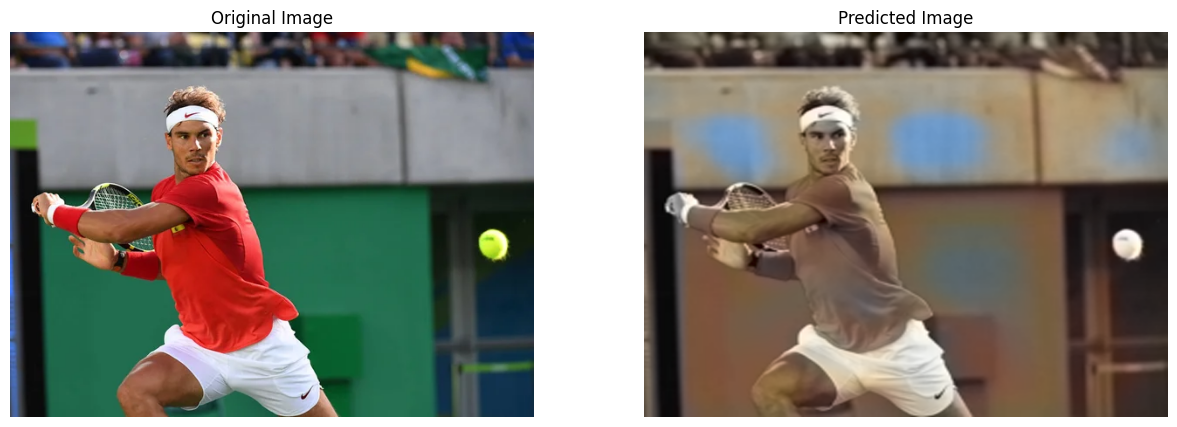

Prediction saved at models/pred_rafa_nadal.jpg


<Figure size 640x480 with 0 Axes>

In [24]:
test_image = "rafa_nadal.jpg"

original_image, pred = predict_image_zhang(
    model=model2,
    image_path=os.path.join(TEST_IMAGE_PATH, test_image),
    device=device,
    size=HYPERPARAMETERS["size"],
)

show_image(original_image, pred, save_path=os.path.join(MODELS_PATH, "pred_" + test_image))